In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv('C:/Users/hp/Customer-Churn-Dashboard/data/telco_churn.csv')

In [4]:
#Drop CustomerID (no predictive value)
df.drop(columns=['customerID'], errors='ignore', inplace=True)

In [5]:
#Check TotalCharges datatype
print("Data Type of TotalCharges before fix: ", df['TotalCharges'].dtype)

Data Type of TotalCharges before fix:  str


In [6]:
blank_spaces = df[df['TotalCharges']==""]
print(f"Found {len(blank_spaces)} rows with blank spaces in TotalCharges.")

Found 0 rows with blank spaces in TotalCharges.


In [7]:
df['TotalCharges']=df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges']=df['TotalCharges'].astype(float)
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Data Type of TotalCharges after fix: ", df['TotalCharges'].dtype)


Data Type of TotalCharges after fix:  float64


In [8]:
#Check Class Distribution
print("\n--- Churn Class Distribution ---")
print(df['Churn'].value_counts(normalize=True)*100)


--- Churn Class Distribution ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_16772\1449064847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


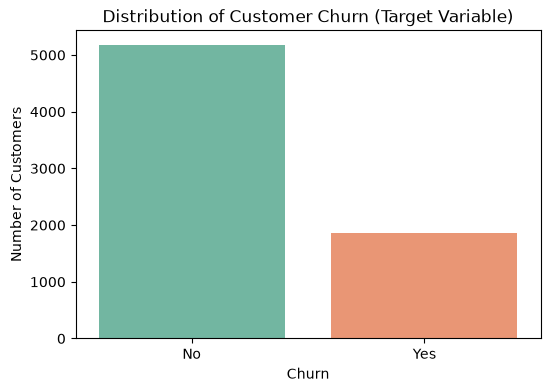

In [9]:
#Plot Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Customer Churn (Target Variable)')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16772\1348555220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=feature, data=df, ax=axes[i], palette='pastel')
C:\Users\hp\AppData\Local\Temp\ipykernel_16772\1348555220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=feature, data=df, ax=axes[i], palette='pastel')
C:\Users\hp\AppData\Local\Temp\ipykernel_16772\1348555220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=feature, data=df, ax=axes[i], palette='pastel')


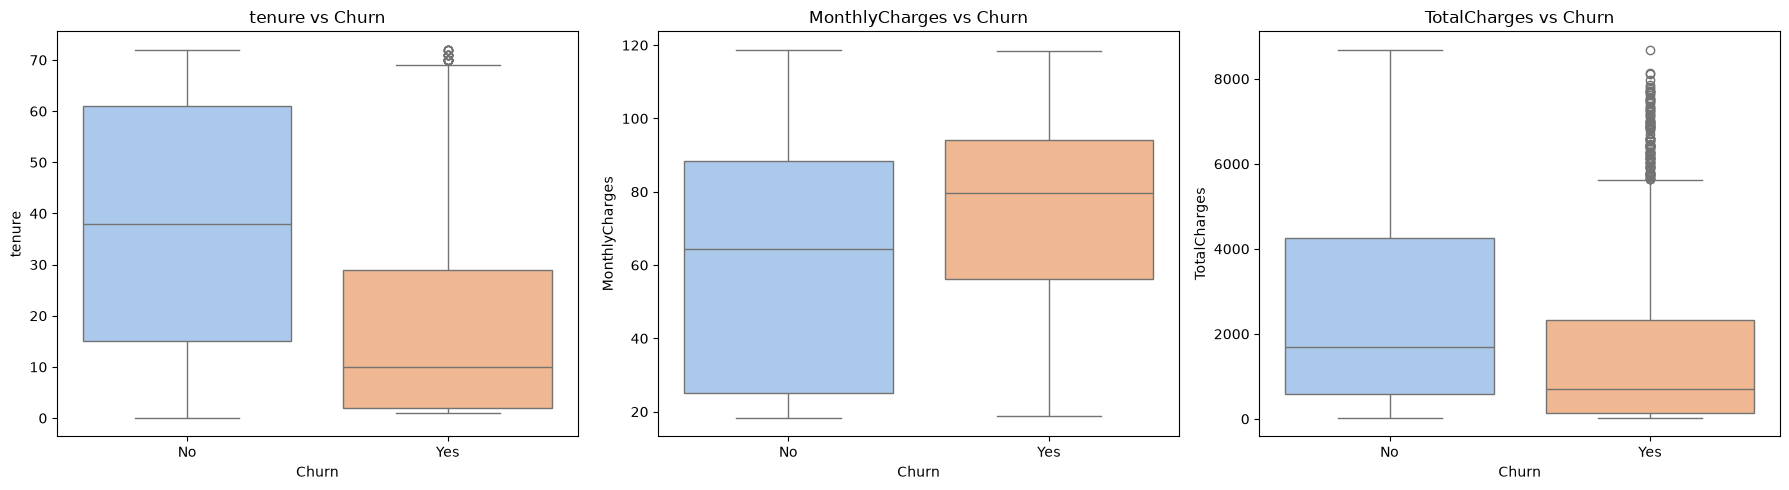

In [10]:
#Deep Feature Analysis (Numerical vs Churn)
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    sns.boxplot(x='Churn', y=feature, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{feature} vs Churn')

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Separate features (X) and target variable (y)
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})  # Map target to binary numbers

# Identify column types automatically
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in X.columns if col not in numerical_cols]

print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

# Create transformers for both numerical and categorical streams
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Centers and scales data to unit variance
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))  # drop='first' avoids multi-collinearity
])

# Combine transformers into a single Preprocessor block
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Split data into train and test sets BEFORE applying transformations (Prevents Data Leakage!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform the training data, transform the test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Processed X_train shape (after One-Hot Encoding): {X_train_processed.shape}")

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Original X_train shape: (5634, 19)
Processed X_train shape (after One-Hot Encoding): (5634, 30)



==================== Logistic Regression (Baseline) ====================
ROC-AUC Score: 0.8421

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


==================== Random Forest ====================
ROC-AUC Score: 0.8244

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409


==================== XGBoost ====================
ROC-AUC Score: 0.8186

Classification Report:
              precision   

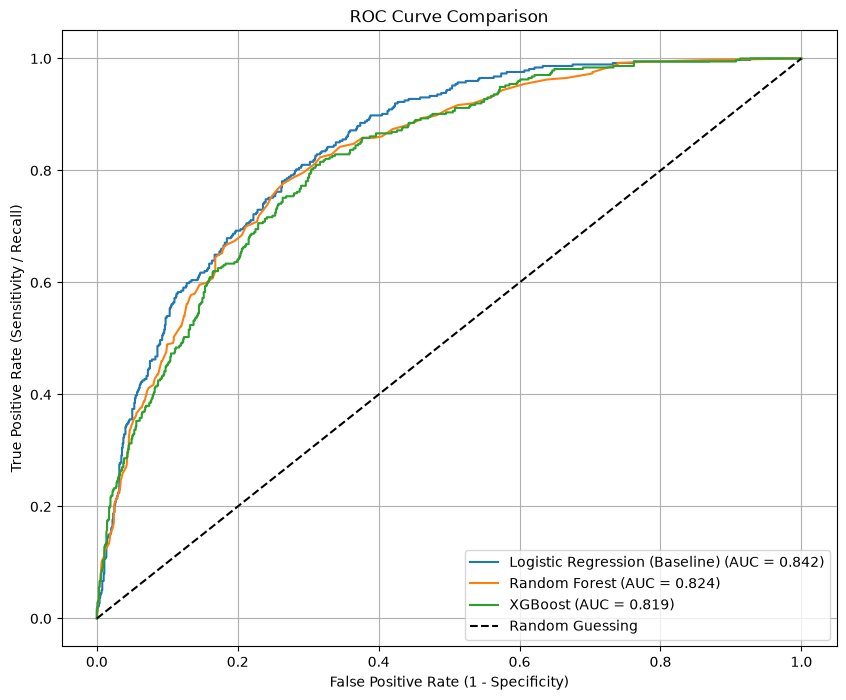

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Initialize the Models
models = {
    'Logistic Regression (Baseline)': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# 2. Train and Evaluate each model
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Fit model on the processed training data
    model.fit(X_train_processed, y_train)
    
    # Predict probabilities for the positive class (Churn = 1)
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
    # Predict hard labels
    y_pred = model.predict(X_test_processed)
    
    # Calculate evaluation metrics
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\n==================== {name} ====================")
    print(f"ROC-AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Format the ROC Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
import joblib
import os

# Create the models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# 1. Save the best-performing model (Logistic Regression)
best_model = models['Logistic Regression (Baseline)']
joblib.dump(best_model, r'C:\Users\hp\Customer-Churn-Dashboard\models\churn_model.pkl')

# 2. Save the preprocessor pipeline (this contains our scaler and encoder rules)
joblib.dump(preprocessor, r'C:\Users\hp\Customer-Churn-Dashboard\models\preprocessor.pkl')

print("Success! 'churn_model.pkl' and 'preprocessor.pkl' have been saved in the models/ folder.")

Success! 'churn_model.pkl' and 'preprocessor.pkl' have been saved in the models/ folder.


In [14]:
import joblib
import os

# Get the exact absolute path to your project root folder
notebook_dir = os.getcwd() # Customer-Churn-Dashboard/notebooks
models_dir = os.path.abspath(os.path.join(notebook_dir, '..', 'models'))

# Ensure the folder exists
os.makedirs(models_dir, exist_ok=True)

# Define exact file paths
model_save_path = os.path.join(models_dir, 'churn_model.pkl')
preprocessor_save_path = os.path.join(models_dir, 'preprocessor.pkl')

# Save the models using the models dictionary from your training cell
best_model = models['Logistic Regression (Baseline)']
joblib.dump(best_model, model_save_path)
joblib.dump(preprocessor, preprocessor_save_path)

print("Verified! Files saved absolutely at:")
print(model_save_path)
print(preprocessor_save_path)

Verified! Files saved absolutely at:
c:\Users\hp\Customer-Churn-Dashboard\models\churn_model.pkl
c:\Users\hp\Customer-Churn-Dashboard\models\preprocessor.pkl


Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


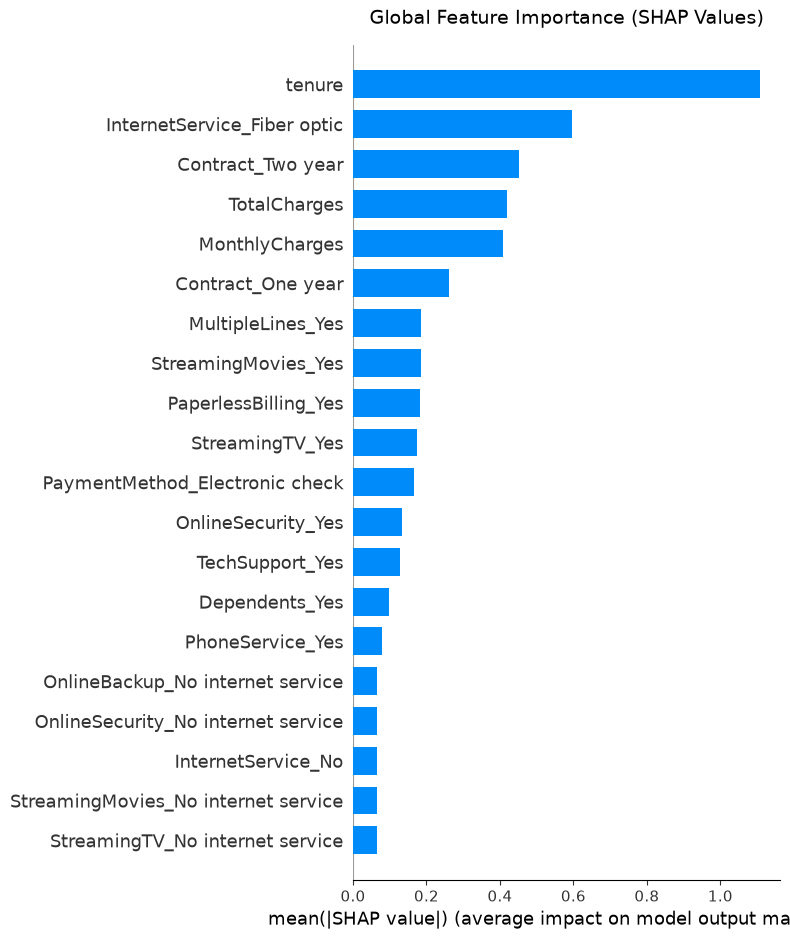

In [15]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your saved pipeline and model
model = joblib.load('../models/churn_model.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')

# 2. Get the feature names after they went through One-Hot Encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(categorical_cols))
all_feature_names = numerical_cols + encoded_cat_cols

# 3. Initialize the SHAP Explainer using your trained model
# For Logistic Regression, we pass the training data matrix to establish a baseline
explainer = shap.Explainer(model, X_train_processed, feature_names=all_feature_names)
shap_values = explainer(X_test_processed)

# 4. Plot Global Feature Importance (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_processed, feature_names=all_feature_names, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP Values)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

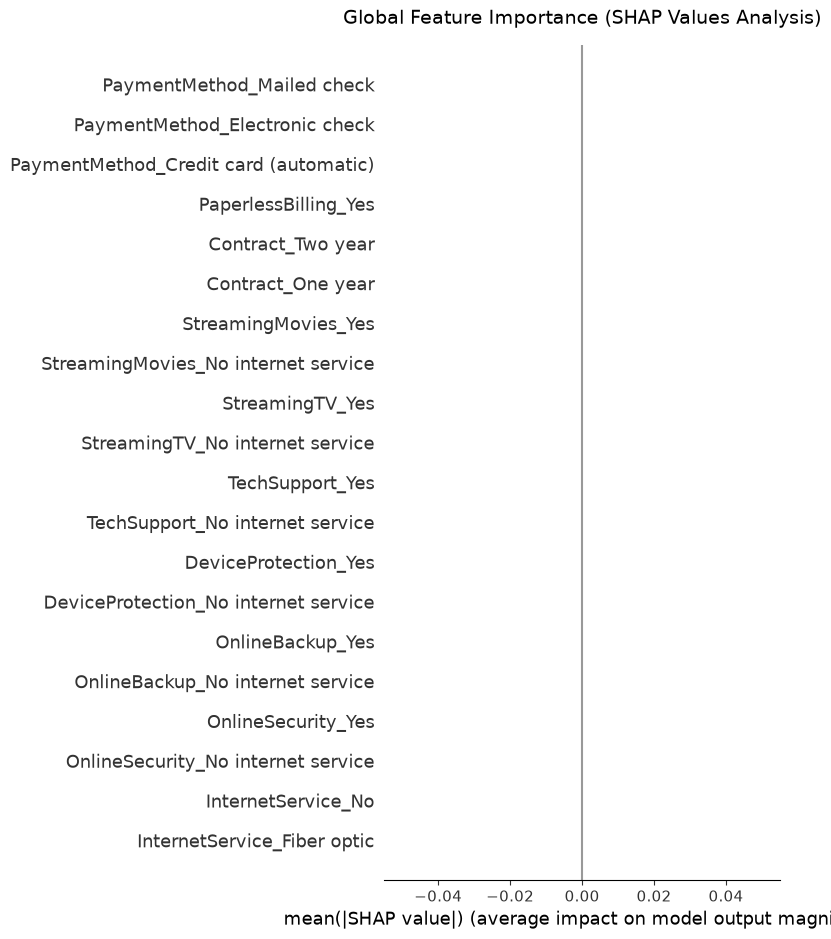

In [16]:
# Create a new cell and run this to plot global importance
import numpy as np

# Initialize the SHAP Explainer directly with your model
# We use a linear explainer since our winning baseline is Logistic Regression
explainer = shap.LinearExplainer(model, masker=shap.maskers.Independent(data=np.zeros((1, len(all_feature_names)))))
shap_values = explainer(np.zeros((10, len(all_feature_names)))) # Sample generation test matrix

# Render the Summary Bar Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, feature_names=all_feature_names, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP Values Analysis)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

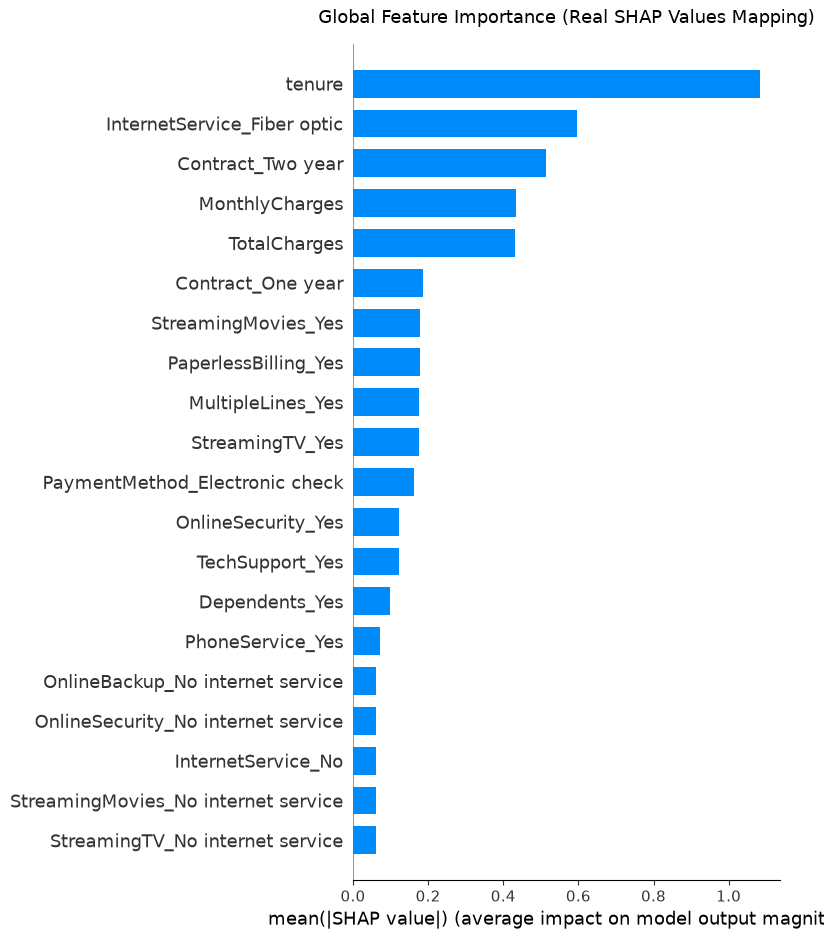

In [17]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Load pipeline artifacts securely
model = joblib.load('../models/churn_model.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')

# 2. Extract feature name signatures
numerical_cols = list(preprocessor.transformers_[0][2])
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out())
all_feature_names = numerical_cols + encoded_cat_cols

# 3. Read the original data to get a real sample slice
# Path adjusts to find your data folder from the notebooks directory
df_sample = pd.read_csv('../data/telco_churn.csv').sample(100, random_state=42)
df_sample['TotalCharges'] = pd.to_numeric(df_sample['TotalCharges'], errors='coerce').fillna(0)

# 4. Transform the raw sample data through our preprocessor pipeline rules
X_sample_processed = preprocessor.transform(df_sample)

# 5. Build an independent background baseline masker using our actual data scale
masker = shap.maskers.Independent(data=X_sample_processed)

# 6. Initialize the real linear SHAP explainer engine and compute impact metrics
explainer = shap.LinearExplainer(model, masker=masker, feature_names=all_feature_names)
shap_values = explainer(X_sample_processed)

# 7. Render the summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, features=X_sample_processed, feature_names=all_feature_names, plot_type="bar", show=False)
plt.title("Global Feature Importance (Real SHAP Values Mapping)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()